# Практика к занятию 7: решающие деревья (Decision Trees)

**Что попробуем**:
- Реализовать простой классификатор-решающее дерево "с нуля" (поддержка критериев: Gini, Entropy).
- Сравнить реализации (собственная vs `sklearn.tree.DecisionTreeClassifier`).
- Пронаблюдать переобучение и способы борьбы с ним (ограничение глубины, `min_samples_leaf`, `ccp_alpha`).
- Визуализировать дерево и извлечь интерпретируемые правила.


In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# Настройки отображения
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.width', 120)


## 1. Датасеты для экспериментов

Мы используем два набора данных:
- **Breast Cancer** (sklearn) - реальный бинарный набор для классификации (подойдёт для ROC/AUC).
- **Synthetic** (make_classification) - чтобы показать переобучение (много признаков, мало информативных).


In [2]:
help(make_classification)

Help on function make_classification in module sklearn.datasets._samples_generator:

make_classification(
    n_samples=100,
    n_features=20,
    *,
    n_informative=2,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    weights=None,
    flip_y=0.01,
    class_sep=1.0,
    hypercube=True,
    shift=0.0,
    scale=1.0,
    shuffle=True,
    random_state=None,
    return_X_y=True
)
    Generate a random n-class classification problem.

    This initially creates clusters of points normally distributed (std=1)
    about vertices of an ``n_informative``-dimensional hypercube with sides of
    length ``2*class_sep`` and assigns an equal number of clusters to each
    class. It introduces interdependence between these features and adds
    various types of further noise to the data.

    Without shuffling, ``X`` horizontally stacks features in the following
    order: the primary ``n_informative`` features, followed by ``n_redundant``
    linear combinat

In [3]:
# Загрузим breast_cancer (binary) и synthetic dataset
bc = datasets.load_breast_cancer(as_frame=True)
X_bc = bc.data
y_bc = bc.target

# Synthetic dataset: небольшое количество информативных фич на фоне шума -> легко переобучается
X_syn, y_syn = make_classification(
    n_samples=400, n_features=30, n_informative=3, n_redundant=5,
    n_repeated=0, n_classes=2, flip_y=0.08, class_sep=1.0, random_state=42
)

X_syn = pd.DataFrame(X_syn, columns=[f'feat_{i}' for i in range(X_syn.shape[1])])
y_syn = pd.Series(y_syn, name='target')

print('Breast cancer data shape:', X_bc.shape)
print('Synthetic data shape:', X_syn.shape)

Breast cancer data shape: (569, 30)
Synthetic data shape: (400, 30)



## 2. Реализация простого Decision Tree (CART-like)

Ниже — минимальная реализация бинарного решающего дерева, поддерживающая:
- критерии качества: **gini** и **entropy**
- параметры регуляризации: `max_depth`, `min_samples_leaf`
- возвращает вероятности классов (важно для ROC AUC)

In [4]:
help(np.bincount)

Help on _ArrayFunctionDispatcher in module numpy:

bincount(...)
    bincount(x, /, weights=None, minlength=0)

    Count number of occurrences of each value in array of non-negative ints.

    The number of bins (of size 1) is one larger than the largest value in
    `x`. If `minlength` is specified, there will be at least this number
    of bins in the output array (though it will be longer if necessary,
    depending on the contents of `x`).
    Each bin gives the number of occurrences of its index value in `x`.
    If `weights` is specified the input array is weighted by it, i.e. if a
    value ``n`` is found at position ``i``, ``out[n] += weight[i]`` instead
    of ``out[n] += 1``.

    Parameters
    ----------
    x : array_like, 1 dimension, nonnegative ints
        Input array.
    weights : array_like, optional
        Weights, array of the same shape as `x`.
    minlength : int, optional
        A minimum number of bins for the output array.

    Returns
    -------
    out 

In [5]:
class SimpleDecisionTreeClassifier:
    """
    Реализация решающего дерева.
    Кодирует метки в 0..n_classes_-1 и гарантирует, что в node['value']
    всегда векторы длины self.n_classes_.
    Поддерживает 'gini' и 'entropy', max_depth, min_samples_leaf.
    """
    def __init__(self, criterion='gini', max_depth=None, min_samples_leaf=1):
        assert criterion in ('gini', 'entropy')
        self.criterion = criterion
        self.max_depth = max_depth if max_depth is None else int(max_depth)
        self.min_samples_leaf = int(min_samples_leaf)

        # будут заполнены в fit()
        self.tree_ = None
        self.n_classes_ = None
        self.classes_ = None
        self.class_to_index_ = None

    def _gini(self, y):
        probs = np.bincount(y, minlength=self.n_classes_) / len(y)
        return 1.0 - np.sum(probs**2)

    def _entropy(self, y):
        probs = np.bincount(y, minlength=self.n_classes_) / len(y)
        probs = probs[probs > 0]
        return -np.sum(probs * np.log2(probs))

    def _impurity(self, y):
        # вычисляет "неопределённость" (impurity) узла, чтобы понимать,
        # насколько неоднородны метки в данной подвыборке
        if len(y) == 0:
            return 0.0
        return self._gini(y) if self.criterion == 'gini' else self._entropy(y)

    def _best_split(self, X, y):
        # Размер выборки и число признаков
        n_samples, n_features = X.shape
        if n_samples <= 1:
            # Невозможно разделить менее одного объекта
            return None, None, None, None

        # Импульс (неопределённость) родительского узла
        parent_impurity = self._impurity(y)

        # Инициализация переменных для лучшего разбиения
        best_gain = 0.0
        best_feat = None
        best_thresh = None
        best_left_idx = None

        # Перебор всех признаков
        for feature in range(n_features):
            values = X[:, feature]
            # Сортировка значений признака для упрощения поиска порогов
            sorted_idx = np.argsort(values)
            values_sorted = values[sorted_idx]
            y_sorted = y[sorted_idx]

            # Рассмотрение всех возможных порогов между соседними значениями
            for i in range(1, n_samples):
                # Пропускаем одинаковые значения
                if values_sorted[i] == values_sorted[i-1]:
                    continue
                # Среднее между соседними значениями как кандидат порога
                thresh = (values_sorted[i] + values_sorted[i-1]) / 2.0

                # Создаем маску для левой и правой подвыборки
                left_mask = values <= thresh
                left_count = np.sum(left_mask)
                right_count = n_samples - left_count

                # Проверяем ограничение на минимальное количество объектов в листе
                if left_count < self.min_samples_leaf or right_count < self.min_samples_leaf:
                    continue

                # Вычисляем impurity (Gini/Entropy) для левой и правой подвыборок
                left_imp = self._impurity(y[left_mask])
                right_imp = self._impurity(y[~left_mask])

                # Взвешенное среднее по числу объектов
                weighted_imp = (left_count * left_imp + right_count * right_imp) / n_samples

                # Прирост информации (или уменьшение impurity)
                gain = parent_impurity - weighted_imp

                # Сохраняем лучшее разбиение
                if gain > best_gain:
                    best_gain = gain
                    best_feat = feature
                    best_thresh = thresh
                    best_left_idx = left_mask

        # Возвращаем лучший признак, порог, маску для левой подвыборки и прирост
        return best_feat, best_thresh, best_left_idx, best_gain


    def _build_tree(self, X, y, depth=0):
        num_samples = X.shape[0]
        num_classes_in_node = len(np.unique(y))
        node = {}
        node['n_samples'] = num_samples
        # гарантируем одинаковую длину value: minlength=self.n_classes_
        node['value'] = np.bincount(y, minlength=self.n_classes_).astype(int).tolist()
        node['predicted_class'] = int(np.argmax(node['value']))

        # условия останова
        if self.max_depth is not None and depth >= self.max_depth:
            node['is_leaf'] = True
            return node

        if num_samples <= 2 * self.min_samples_leaf or num_classes_in_node == 1:
            node['is_leaf'] = True
            return node

        feat, thresh, left_mask, gain = self._best_split(X, y)
        if feat is None or gain <= 0:
            node['is_leaf'] = True
            return node

        node['is_leaf'] = False
        node['feature'] = int(feat)
        node['threshold'] = float(thresh)
        node['left'] = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        node['right'] = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        return node

    def fit(self, X, y):
        # Поддержка pandas
        if isinstance(X, pd.DataFrame):
            X = X.values
        if isinstance(y, (pd.Series, pd.DataFrame)):
            y_arr = np.asarray(y).ravel()
        else:
            y_arr = np.asarray(y)

        # Кодируем метки в 0..n_classes_-1
        self.classes_, y_encoded = np.unique(y_arr, return_inverse=True)
        self.n_classes_ = len(self.classes_)
        # map original -> encoded index (необязательно, но удобно)
        self.class_to_index_ = {c: i for i, c in enumerate(self.classes_)}

        self.n_features_ = X.shape[1]
        # строим дерево на закодированных метках
        self.tree_ = self._build_tree(X, y_encoded, depth=0)
        return self

    def _predict_one(self, x, node):
        if node.get('is_leaf', True):
            return node['predicted_class']
        if x[node['feature']] <= node['threshold']:
            return self._predict_one(x, node['left'])
        else:
            return self._predict_one(x, node['right'])

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        preds_idx = [self._predict_one(x, self.tree_) for x in X]
        # преобразуем индексы обратно в оригинальные метки
        return np.array([self.classes_[i] for i in preds_idx])

    def _predict_proba_one(self, x, node):
        if node.get('is_leaf', True):
            counts = np.array(node['value'], dtype=float)
            probs = counts / counts.sum() if counts.sum() > 0 else np.zeros(self.n_classes_, dtype=float)
            return probs
        if x[node['feature']] <= node['threshold']:
            return self._predict_proba_one(x, node['left'])
        else:
            return self._predict_proba_one(x, node['right'])

    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        probs = np.vstack([self._predict_proba_one(x, self.tree_) for x in X])
        return probs

## 3. Сравнение: наша реализация vs sklearn

На примере Breast Cancer

In [6]:
def print_metrics(name, y_true, y_pred, y_prob=None):
    print(f'-- {name} --')
    print('Accuracy:', accuracy_score(y_true, y_pred))
    print('Precision:', precision_score(y_true, y_pred))
    print('Recall:', recall_score(y_true, y_pred))
    print('F1:', f1_score(y_true, y_pred))
    if y_prob is not None:
        try:
            print('ROC AUC:', roc_auc_score(y_true, y_prob))
        except Exception as e:
            print('ROC AUC: error', e)
    print('Confusion matrix:\n', confusion_matrix(y_true, y_pred))
    print()

In [7]:
# train/test split
X = X_bc.copy()
y = y_bc.copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Train our simple tree (gini) and sklearn tree with similar parameters
simple_tree = SimpleDecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=5)
simple_tree.fit(X_train, y_train)

sk_tree = DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=5, random_state=42)
sk_tree.fit(X_train, y_train)

# Predictions & probabilities
y_pred_simple = simple_tree.predict(X_test)
y_pred_sk = sk_tree.predict(X_test)
y_prob_simple = simple_tree.predict_proba(X_test)[:, 1]  # probability for class 1
y_prob_sk = sk_tree.predict_proba(X_test)[:, 1]

# Metrics function
print_metrics('Simple tree (gini)', y_test, y_pred_simple, y_prob_simple)
print_metrics('sklearn tree (gini)', y_test, y_pred_sk, y_prob_sk)

-- Simple tree (gini) --
Accuracy: 0.9370629370629371
Precision: 0.945054945054945
Recall: 0.9555555555555556
F1: 0.9502762430939227
ROC AUC: 0.9322851153039833
Confusion matrix:
 [[48  5]
 [ 4 86]]

-- sklearn tree (gini) --
Accuracy: 0.9300699300699301
Precision: 0.9444444444444444
Recall: 0.9444444444444444
F1: 0.9444444444444444
ROC AUC: 0.9314465408805032
Confusion matrix:
 [[48  5]
 [ 5 85]]



### Визуализация sklearn дерева и извлечение правил

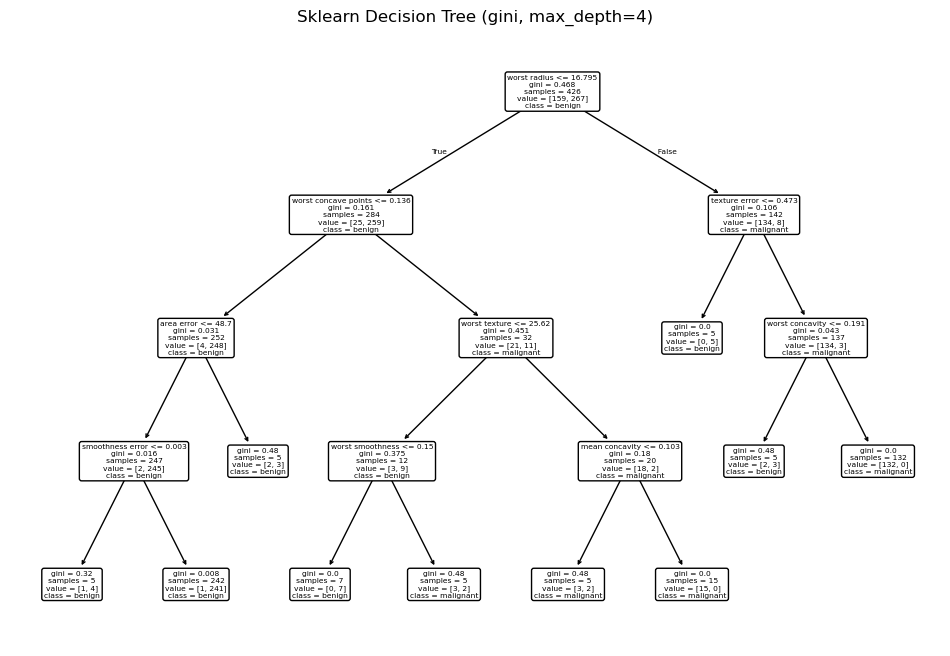

Extracted rules (sklearn):

|--- worst radius <= 16.80
|   |--- worst concave points <= 0.14
|   |   |--- area error <= 48.70
|   |   |   |--- smoothness error <= 0.00
|   |   |   |   |--- class: 1
|   |   |   |--- smoothness error >  0.00
|   |   |   |   |--- class: 1
|   |   |--- area error >  48.70
|   |   |   |--- class: 1
|   |--- worst concave points >  0.14
|   |   |--- worst texture <= 25.62
|   |   |   |--- worst smoothness <= 0.15
|   |   |   |   |--- class: 1
|   |   |   |--- worst smoothness >  0.15
|   |   |   |   |--- class: 0
|   |   |--- worst texture >  25.62
|   |   |   |--- mean concavity <= 0.10
|   |   |   |   |--- class: 0
|   |   |   |--- mean concavity >  0.10
|   |   |   |   |--- class: 0
|--- worst radius >  16.80
|   |--- texture error <= 0.47
|   |   |--- class: 1
|   |--- texture error >  0.47
|   |   |--- worst concavity <= 0.19
|   |   |   |--- class: 1
|   |   |--- worst concavity >  0.19
|   |   |   |--- class: 0



In [8]:
plt.figure(figsize=(12,8))
plot_tree(sk_tree, feature_names=X.columns, class_names=bc.target_names, filled=False, rounded=True)
plt.title('Sklearn Decision Tree (gini, max_depth=4)')
plt.show()

# Text rules from sklearn
rules = export_text(sk_tree, feature_names=list(X.columns))
print('Extracted rules (sklearn):\n')
print(rules[:1000])  # печатаем начало (можно прокрутить)


## 4. Демонстрация переобучения (Synthetic dataset)

Натренируем дерево с большой максимальной глубиной и покажем, что оно переобучается.
Затем применим регулизацию (ограничение глубины и min_samples_leaf) и сравним метрики.

In [9]:
# Helper to evaluate different depths
def evaluate_depths(depths, min_samples_leaf=1):
    train_scores = []
    test_scores = []
    for d in depths:
        clf = DecisionTreeClassifier(max_depth=d, min_samples_leaf=min_samples_leaf, random_state=42)
        clf.fit(X_train_s, y_train_s)
        train_scores.append(clf.score(X_train_s, y_train_s))
        test_scores.append(clf.score(X_test_s, y_test_s))
    return train_scores, test_scores

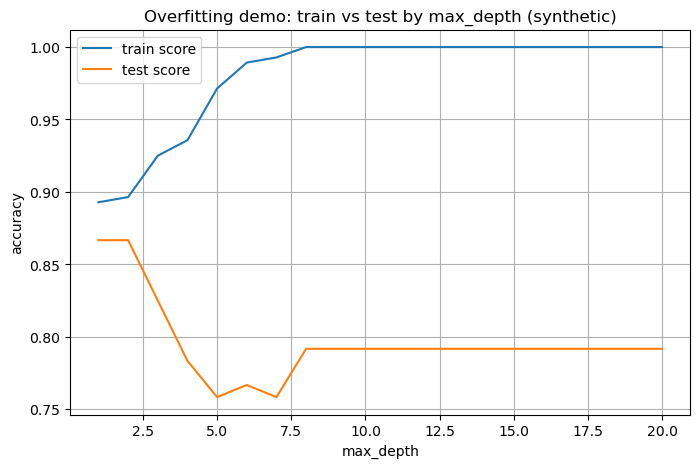

In [10]:
# Train/test split for synthetic
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_syn, y_syn, test_size=0.3, random_state=42, stratify=y_syn)

depths = list(range(1, 21))
train_scores, test_scores = evaluate_depths(depths, min_samples_leaf=1)

plt.figure(figsize=(8,5))
plt.plot(depths, train_scores, label='train score')
plt.plot(depths, test_scores, label='test score')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.title('Overfitting demo: train vs test by max_depth (synthetic)')
plt.legend()
plt.grid(True)
plt.show()

## 5. Регуляризация

Покажем влияние `min_samples_leaf` и `ccp_alpha` (скользящая регуляризация стоимости сложности) на качество.

   min_samples_leaf  train_acc  test_acc
0                 1   1.000000  0.791667
1                 5   0.939286  0.833333
2                10   0.914286  0.841667
3                20   0.900000  0.833333
4                50   0.892857  0.866667

Number of candidate alphas: 14


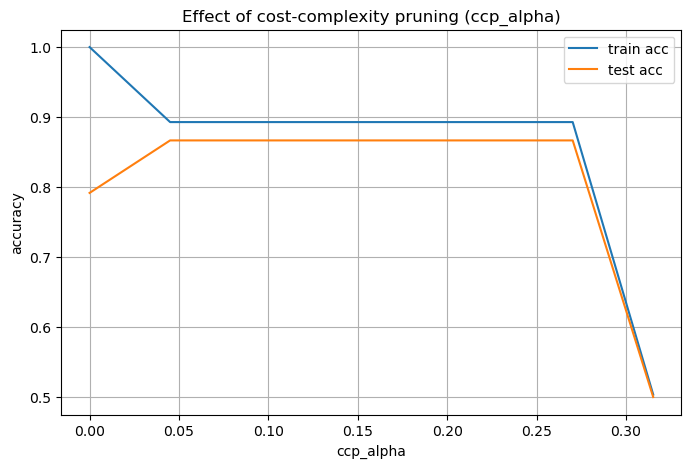

In [11]:
# Vary min_samples_leaf
leaf_vals = [1, 5, 10, 20, 50]
results = []
for leaf in leaf_vals:
    clf = DecisionTreeClassifier(max_depth=None, min_samples_leaf=leaf, random_state=42)
    clf.fit(X_train_s, y_train_s)
    results.append((leaf, clf.score(X_train_s, y_train_s), clf.score(X_test_s, y_test_s)))

df_res = pd.DataFrame(results, columns=['min_samples_leaf', 'train_acc', 'test_acc'])
print(df_res)

# Cost complexity pruning path (sklearn) - compute effective alphas
clf_full = DecisionTreeClassifier(random_state=42)
path = clf_full.cost_complexity_pruning_path(X_train_s, y_train_s)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
print('\nNumber of candidate alphas:', len(ccp_alphas))

# Train trees for some alphas and plot test accuracy
train_scores = []
test_scores = []
alphas_to_test = np.linspace(ccp_alphas.min(), ccp_alphas.max(), num=8)
for a in alphas_to_test:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=float(a))
    clf.fit(X_train_s, y_train_s)
    train_scores.append(clf.score(X_train_s, y_train_s))
    test_scores.append(clf.score(X_test_s, y_test_s))

plt.figure(figsize=(8,5))
plt.plot(alphas_to_test, train_scores, label='train acc')
plt.plot(alphas_to_test, test_scores, label='test acc')
plt.xlabel('ccp_alpha')
plt.ylabel('accuracy')
plt.title('Effect of cost-complexity pruning (ccp_alpha)')
plt.legend()
plt.grid(True)
plt.show()


## 6. Извлечение правил из собственной реализации

Функция ниже рекурсивно обходит дерево и выводит правила в виде текста — удобно для бизнес-правил и экспертных систем.


In [12]:
def tree_to_rules(node, feature_names, prefix='IF '):
    # returns list of strings, each is a rule leading to a leaf with prediction and samples
    if node.get('is_leaf', True):
        prob = np.array(node['value'], dtype=float)
        prob = prob / prob.sum()
        return [f"{prefix} THEN predict={node['predicted_class']} (samples={node['n_samples']}, prob={prob.tolist()})"]
    # left rule
    f = feature_names[node['feature']]
    thresh = node['threshold']
    left_prefix = prefix + f"{f} <= {thresh:.4f} AND "
    right_prefix = prefix + f"{f} > {thresh:.4f} AND "
    left_rules = tree_to_rules(node['left'], feature_names, left_prefix)
    right_rules = tree_to_rules(node['right'], feature_names, right_prefix)
    return left_rules + right_rules

print('Rules from simple_tree:')
rules = tree_to_rules(simple_tree.tree_, list(X.columns))
for r in rules[:10]:
    print(r)

Rules from simple_tree:
IF worst radius <= 16.7950 AND worst concave points <= 0.1359 AND radius error <= 0.6256 AND smoothness error <= 0.0034 AND  THEN predict=1 (samples=5, prob=[0.2, 0.8])
IF worst radius <= 16.7950 AND worst concave points <= 0.1359 AND radius error <= 0.6256 AND smoothness error > 0.0034 AND  THEN predict=1 (samples=242, prob=[0.004132231404958678, 0.9958677685950413])
IF worst radius <= 16.7950 AND worst concave points <= 0.1359 AND radius error > 0.6256 AND  THEN predict=1 (samples=5, prob=[0.4, 0.6])
IF worst radius <= 16.7950 AND worst concave points > 0.1359 AND worst texture <= 25.6200 AND mean smoothness <= 0.1087 AND  THEN predict=1 (samples=7, prob=[0.0, 1.0])
IF worst radius <= 16.7950 AND worst concave points > 0.1359 AND worst texture <= 25.6200 AND mean smoothness > 0.1087 AND  THEN predict=0 (samples=5, prob=[0.6, 0.4])
IF worst radius <= 16.7950 AND worst concave points > 0.1359 AND worst texture > 25.6200 AND mean concavity <= 0.1027 AND  THEN pre